## Init

In [189]:
import numpy as np
import scipy.constants as phy_const
import matplotlib.pyplot as plt
import pickle

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import os
import pandas as pd
import pickle
import glob
import sys
import configparser

from matplotlib import rcParams as rc
rc["mathtext.fontset"] = "stix"
rc["font.family"] = "STIXGeneral"

# Enable LaTeX rendering
plt.rcParams['text.usetex'] = True
plt.rc("text", usetex=True)


In [190]:
def compute_phi(P, Current):
    def cumtrapz(y, d):
        return np.concatenate((np.zeros(1), np.cumsum(d * (y[1:] + y[:-1]) / 2.0)))
    
    E   = compute_E(P, Current)
    phi = V - Current * Rext - cumtrapz(E, d=Delta_x)  # Discharge electrostatic potential
    return phi
    
def compute_E(P, Current):

    def compute_Kel(Te):
        # Xenon
        a =  6.25621116e-14
        b = -4.30874715e+00
        c = -1.45152836e+01
        d = -1.49229954e+01
        e = -5.68651763e+00
        f = 3.36357165e-01

        t = (1/Te)

        return 16./3.*a*t**f*np.exp(-b*t+ c*t**2 - d*t**3. + e*t**4)
    
    def trapz(y, d):
        return np.sum( (y[1:] + y[:-1]) )*d/2.0
    def gradient(y, d):
        dp_dz = np.empty_like(y)
        dp_dz[1:-1] = (y[2:] - y[:-2]) / (2 * d)
        dp_dz[0] = 2 * dp_dz[1] - dp_dz[2]
        dp_dz[-1] = 2 * dp_dz[-2] - dp_dz[-3]

        return dp_dz

    # TODO: This is already computed! Maybe move to the source
    #############################################################
    #       We give a name to the vars to make it more readable
    #############################################################
    ng = P[0,:]
    ni = P[1,:]
    ui = P[2,:]
    Te = P[3,:]
    ve = P[4,:]
    Gamma_i = ni*ui
    wce     = phy_const.e*B/m              # electron cyclotron frequency
    
    #############################
    #       Compute the rates   #
    #############################
    Kel = compute_Kel(Te)  # Electron - neutral  collision rate     TODO: Replace by good one

    ############################
    #       Wall Collisions    # 
    ############################     
    sigma      = 0.207*Te**(0.549)
    sigma_scl  = 1. - 8.3*np.sqrt(m/M)
    sigma[sigma > sigma_scl] = sigma_scl
    nu_iw      = 2 * 0.5 * (1.0 / (R2 - R1)) * np.sqrt(phy_const.e * Te / M)
    index_L0 = np.argmax(x_center > L0)
    nu_iw[index_L0:] = 0.0
    nu_ew      =  nu_iw / (1 - sigma)                                        # Electron - wall collision rate

    # TODO: OLD
    # sigma_old = 2.0 * Te / Estar  # SEE yield
    # sigma_old[sigma_old > 0.986] = 0.986
    # nu_iw = (
    #     (4.0 / 3.0) * (1.0 / (R2 - R1)) * np.sqrt(phy_const.e * Te / M)
    # )  # Ion - wall collision rate d
    # # Limit the collisions to inside the thruster
    # index_L0 = np.argmax(x_center > L0)
    # nu_iw[index_L0:] = 0.0

    alpha_B = (np.ones(NBPOINTS) * alpha_B1)                                                # Anomalous transport coefficient inside the thruster
    alpha_B = np.where(x_center < L0, alpha_B, alpha_B2)                                    # Anomalous transport coefficient in the plume
    alpha_B_smooth = np.copy(alpha_B)

    # smooth between alpha_B1 and alpha_B2
    for index in range(10, NBPOINTS - 9):
        alpha_B_smooth[index] = np.mean(alpha_B[index-10:index+10])
    alpha_B = alpha_B_smooth

    nu_m   = ng*Kel + alpha_B*wce + nu_ew                          # Electron momentum - transfer collision frequency
    
    mu_eff = (phy_const.e/(m*nu_m))*(1./(1 + (wce/nu_m)**2))       # Effective mobility
    dp_dz  = gradient(ni*Te, d = Delta_x)
    
    I0 = Current/(phy_const.e*A0)
    
    E = (I0 - Gamma_i) / (mu_eff * ni) - dp_dz / ni  # Discharge electric field
    return E


In [197]:
##########################################################
#           POST-PROC PARAMETERS
##########################################################
Results     = "Results_SPT_1/test_15/"
Results     = "Results_SPT_2/test_15c/"
PLOT_VARS   = True
ResultConfig = Results+'/Configuration.cfg'


In [211]:

##########################################################
#           CONFIGURE PHYSICAL PARAMETERS
##########################################################

configFile = ResultConfig
config = configparser.ConfigParser()
config.read(configFile)

physicalParameters = config['Physical Parameters']

VG       = float(physicalParameters['Gas velocity'])                 # Gas velocity
M        = float(physicalParameters['Ion Mass'])*phy_const.m_u       # Ion Mass
m        = phy_const.m_e                                             # Electron mass
R1       = float(physicalParameters['Inner radius'])                 # Inner radius of the thruster
R2       = float(physicalParameters['Outer radius'])                 # Outer radius of the thruster
A0       = np.pi * (R2 ** 2 - R1 ** 2)                               # Area of the thruster
LENGTH   = float(physicalParameters['Length of axis'])               # length of Axis of the simulation
L0       = float(physicalParameters['Length of thruster'])           # length of thruster (position of B_max)
alpha_B1 = float(physicalParameters["Anomalous transport alpha_B1"])  # Anomalous transport
alpha_B2 = float(physicalParameters["Anomalous transport alpha_B2"])  # Anomalous transport
mdot     = float(physicalParameters['Mass flow'])                    # Mass flow rate of propellant
Te_Cath  = float(physicalParameters['Temperature Cathode'])          # Electron temperature at the cathode
Rext     = float(physicalParameters['Ballast resistor'])             # Resistor of the ballast
V0       = float(physicalParameters['Voltage'])                      # Potential difference
Estar    = float(physicalParameters['Crossover energy'])             # Crossover energy

##########################################################
#           NUMERICAL PARAMETERS
##########################################################
NumericsConfig = config['Numerical Parameteres']

NBPOINTS  = int(NumericsConfig['Number of points'])             # Number of cells
SAVERATE  = int(NumericsConfig['Save rate'])                    # Rate at which we store the data
CFL       = float(NumericsConfig['CFL'])                        # Nondimensional size of the time step
TIMEFINAL = float(NumericsConfig['Final time'])                 # Last time of simulation
Results   = NumericsConfig['Result dir']                        # Name of result directory
TIMESCHEME = NumericsConfig['Time integration']                        # Name of result directory

Delta_x  = LENGTH/NBPOINTS

##########################################################
#           Make the plots
#########################################################

# plt.style.use('classic')
# plt.rcParams["font.family"] = 'serif'
# plt.rcParams["font.weight"] = 'normal'
# plt.rcParams['figure.facecolor'] = 'white'
# plt.rcParams["font.size"] = 15
# plt.rcParams["lines.linewidth"] = 2

ResultsFigs = Results+"/Figs"
ResultsData = Results+"/Data"
if not os.path.exists(ResultsFigs):
    os.makedirs(ResultsFigs)

# open all the files in the directory and sort them to do the video in order
files       = glob.glob(ResultsData + "/*.pkl")
filesSorted = sorted(files, key = lambda x: os.path.getmtime(x), reverse=True)
files.sort(key=os.path.getmtime)
files = files[:]


In [212]:

Current = np.zeros(np.shape(files)[0])
Voltage = np.zeros(np.shape(files)[0])
time    = np.zeros(np.shape(files)[0])


#####################################
#           Plot variables
#####################################

for i_save, file in enumerate(files):
    
    with open(file, 'rb') as f:
        [t, P, U, P_Inlet, P_Outlet, J, V, B, x_center] = pickle.load(f)
    
    # Save the current
    Current[i_save] = J
    Voltage[i_save] = V
    time[i_save]    = t

#####################################
#           Plot current
#####################################


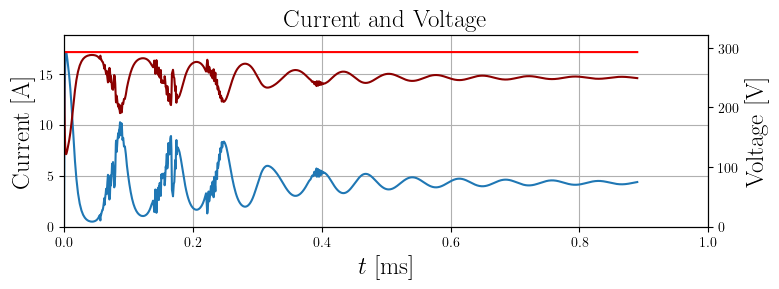

In [213]:
f, ax = plt.subplots(figsize=(8,3))
ax.plot(time/1e-3, Current)
ax.set_xlabel(r'$t$ [ms]', fontsize=18, weight = 'bold')
ax.set_ylabel(r'Current [A]', fontsize=18)
ax_V=ax.twinx()
ax_V.plot(time/1e-3, Voltage,'r')
ax_V.plot(time/1e-3, Voltage - Current * 10,'darkred')
ax_V.set_ylabel(r'Voltage [V]', fontsize=18)
ax.grid(True)
ax.set_title('Current and Voltage', fontsize=18)
# ax.set_xlim(0, time[-1]/1e-3)
ax.set_ylim(0, 1.1*Current.max())
ax.set_xlim(0, 1)
ax_V.set_ylim(0, 1.1*Voltage.max())
ax.tick_params(axis='y', labelcolor='black')
plt.tight_layout()
plt.savefig(ResultsFigs+"/Current.pdf", bbox_inches='tight')

<>:102: SyntaxWarning: invalid escape sequence '\m'
<>:102: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_13759/1091190491.py:102: SyntaxWarning: invalid escape sequence '\m'
  title = "time = " + str(round(t / 1e-6, 4)) + "$\mu$s"


Processing file number: 1414


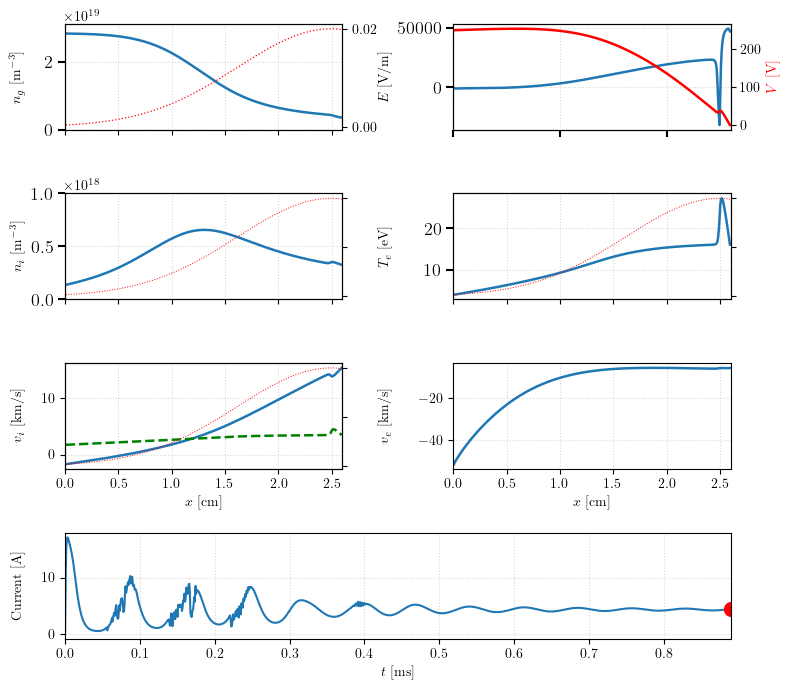

In [214]:
for i_save, file in enumerate(files[-1:]):

    # print("Preparing plot for i = ", i_save)
    #
    file_number = files.index(file)
    print(f"Processing file number: {file_number}")

    with open(file, "rb") as f:
        [t, P, U, P_Inlet, P_Outlet, J, V, B, x_center] = pickle.load(f)

    E = compute_E(P, J)
    phi = compute_phi(P, J)

    fig = plt.figure(figsize=(8, 7))
    gls = fig.add_gridspec(4, 2)
    ax1 = fig.add_subplot(gls[0, 0])
    ax2 = fig.add_subplot(gls[0, 1])
    ax3 = fig.add_subplot(gls[1, 0])
    ax4 = fig.add_subplot(gls[1, 1])
    ax5 = fig.add_subplot(gls[2, 0])
    ax6 = fig.add_subplot(gls[2, 1])
    ax7 = fig.add_subplot(gls[3, :])

    ax = [ax1, ax2, ax3, ax4, ax5, ax6, ax7]

    ax_b = ax[0].twinx()
    ax[0].plot(x_center * 100, P[0, :], linewidth=1.8, markersize=3)
    ax_b.plot(x_center * 100, B, "r:", linewidth=0.9, markersize=3)
    ax_b.set_yticks([0, max(B)])
    # ax_b.set_ylabel(r'$B$ [T]', color='r')
    # ax[0].set_xlabel(r'$x~[m]$')
    ax[0].set_ylabel(r"$n_g$ [m$^{-3}$]")
    # ax[0].xaxis.set_tick_params(which='both', size=0, width=1.5, labelsize=0)
    ax[0].set_xticklabels([])
    ax[0].yaxis.set_tick_params(which="both", size=5, width=1.5, labelsize=13)
    # ax[0].legend(loc = 'lower center', fontsize = 12)
    ax[0].set_ylim([0, max(P[0, :]) * 1.1])

    ax_phi = ax[1].twinx()
    ax[1].plot(x_center * 100, E, linewidth=1.8, markersize=3)
    ax_phi.plot(x_center * 100, phi, color="r", linewidth=1.8, markersize=3)
    ax_phi.set_ylabel(r"$V$ [V]", color="r")
    ax[1].set_ylabel(r"$E$ [V/m]")
    ax[1].set_xticklabels([])
    ax[1].xaxis.set_tick_params(which="both", size=5, width=1.5, labelsize=13)
    ax[1].yaxis.set_tick_params(which="both", size=5, width=1.5, labelsize=13)

    ax_b = ax[2].twinx()
    ax[2].plot(x_center * 100, P[1, :], linewidth=1.8, markersize=3)
    ax_b.plot(x_center * 100, B, "r:", linewidth=0.7, markersize=3)
    ax_b.set_yticklabels([])
    # ax[2].set_xlabel(r'$x~[m]$')
    ax[2].set_ylabel(r"$n_i$ [m$^{-3}$]")
    # ax[2].xaxis.set_tick_params(which='both', size=0, width=1.5, labelsize=0)
    ax[2].set_xticklabels([])
    ax[2].yaxis.set_tick_params(which="both", size=5, width=1.5, labelsize=13)
    # ax[1].legend(loc = 'lower center', fontsize = 12)

    max_ni = 1e17
    if max(P[1, :]) > 1e18:
        max_ni = max(P[1, :]) * 1.5
    elif max(P[1, :]) > 1e17:
        max_ni = 1e18
    else:
        max_ni = 1e17

    ax[2].set_ylim([0, max_ni])

    ax_b = ax[3].twinx()
    ax[3].plot(x_center * 100, P[3, :], linewidth=1.8, markersize=3)
    ax_b.plot(x_center * 100, B, "r:", linewidth=0.7, markersize=3)
    ax_b.set_yticklabels([])
    # ax[3].set_xlabel(r'$x~[m]$')
    ax[3].set_ylabel(r"$T_e$ [eV]")
    # ax[3].xaxis.set_tick_params(which='both', size=0, width=1.5, labelsize=0)
    ax[3].set_xticklabels([])
    ax[3].yaxis.set_tick_params(which="both", size=5, width=1.5, labelsize=13)
    # ax[3].legend(loc = 'lower center', fontsize = 12)
    # f.suptitle('t = ', fontname = 'Times New Roman',fontsize=16)

    ax_b = ax[4].twinx()
    ax[4].plot(x_center * 100, P[2, :] / 1000, linewidth=1.8, markersize=3)
    ax[4].plot(
        x_center * 100,
        np.sqrt(phy_const.e * P[3, :] / (131.293 * phy_const.m_u)) / 1000.0,
        "g--",
        linewidth=1.8,
        markersize=3,
    )
    ax_b.plot(x_center * 100, B, "r:", linewidth=0.7, markersize=3)
    ax_b.set_yticklabels([])
    # ax[4].set_xlabel(r'$x~[m]$')
    ax[4].set_ylabel(r"$v_i$ [km/s]")
    # ax[4].xaxis.set_tick_params(which='both', size=0, width=1.5, labelsize=0)
    # ax[4].set_xticklabels([])
    # ax[4].yaxis.set_tick_params(which='both', size=5, width=1.5, labelsize=13)
    # ax[4].legend(loc="lower center", fontsize=12)

    ax[5].plot(x_center * 100, P[4, :] / 1000, linewidth=1.8, markersize=3)
    ax[5].set_ylabel(r"$v_e$ [km/s]")
    # ax[4].legend(loc = 'lower center', fontsize = 12)
    title = "time = " + str(round(t / 1e-6, 4)) + "$\mu$s"
    # f[0].suptitle(title, y=1.05)

    ax[6].plot(time / 1e-3, Current)
    ax[6].set_ylabel(r"Current [A]")
    ax[6].set_xlabel(r"time [ms]")
    ax[6].plot(time[file_number] / 1e-3, Current[file_number], "ro", markersize=10)
    ax[6].grid(True)
    ax[6].set_xlim([0, time[-1] / 1e-3])
    ax[6].set_xlim([0, 1])

    for axis in ax:
        axis.grid(True)
        # axis.get_legend().remove()

    # ax[0].legend(fontsize=10, loc="lower right")
    plt.tight_layout()

    plt.subplots_adjust(wspace=0.4, hspace=0.4)
    gls.update(hspace=0.6)

    fig.align_labels()

    for axx in ax:
        # axx.label_outer()
        # axx.xaxis.set_tick_params(which='both', size=5, width=1.5, labelsize=13)
        # axx.yaxis.set_tick_params(which='both', size=5, width=1.5, labelsize=13)
        axx.grid(True, which="both", linestyle=":", alpha=0.5)
        if axx != ax[6]:
            axx.set_xlim([0, LENGTH * 100])
            if axx == ax[5] or axx == ax[4]:
                axx.set_xlabel(r"$x$~[cm]")
        else:
            axx.set_xlabel(r"$t$~[ms]")
            axx.set_xlim([0, time[-1] / 1e-3])

    # plt.savefig(ResultsFigs+"/MacroscopicVars_New_"+str(i_save)+".png", bbox_inches='tight')
    # plt.close()

Te_Cathode =  15.0 16.12946659892623
Te_extrap =  14.981995376645475


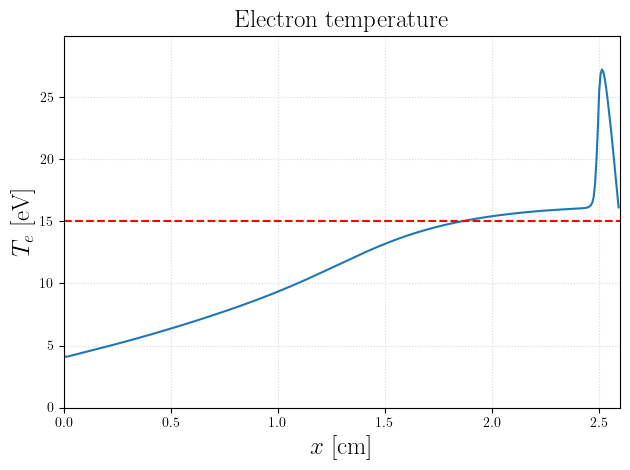

In [215]:
with open(files[-1], "rb") as f:
    [t, P, U, P_Inlet, P_Outlet, J, V, B, x_center] = pickle.load(f)
ng = P[0,:]
ni = P[1,:]
ui = P[2,:]
Te = P[3,:]
ve = P[4,:]

print("Te_Cathode = ", Te_Cath, Te[-1])
delta_Te = Te[-1] - Te[-2]
Te_extrap = Te[-1] + delta_Te
print("Te_extrap = ", Te_extrap)
plt.figure()
plt.plot(x_center*100, Te)
plt.axhline(y=Te_Cath, color='r', linestyle='--')
plt.xlabel(r'$x$ [cm]', fontsize=18)
plt.ylabel(r'$T_e$ [eV]', fontsize=18)
plt.title('Electron temperature', fontsize=18)
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.xlim(0, LENGTH*100)
plt.ylim(0, 1.1*Te.max())
plt.tight_layout()



In [216]:
def compute_Kel(Te):
    """This function calculates the ionization rate"""
    # Polynomial coefficients
    c0 = -3.04474930e+01
    c1 = 1.89683694e+00
    c2 = -6.63807968e-01
    c3 = 9.37924042e-03
    c4 = 2.19404998e-02
    c5 = -2.27126387e-03

    # Compute the natural logarithm of Te
    log_Te = np.log(Te)

    # Manually evaluate the polynomial using Horner's method (unrolled loop)
    result = c5
    result = result * log_Te + c4
    result = result * log_Te + c3
    result = result * log_Te + c2
    result = result * log_Te + c1
    result = result * log_Te + c0

    # Return the exponential of the polynomial result
    return np.exp(result)

def compute_Kiz(Te):
    # Xenon ionization
    K0      = 1.18122959e-13
    epsilon = 12.13
    A       = 1.29330521e-01
    B       = 1.00068880e-02
    C       = 6.97445869e-01

    return K0*np.exp(-epsilon/Te)*(np.log(1 + A*Te + B*Te**2))**C

In [217]:
import pandas as pd
ng = P[0,:]
ni = P[1,:]
ui = P[2,:]
Te = P[3,:]
ve = P[4,:]
Gamma_i = ni*ui
wce     = phy_const.e*B/m              # electron cyclotron frequency

#############################
#       Compute the rates   #
#############################


Kel = compute_Kel(Te)  # Electron - neutral  collision rate 
Kiz = compute_Kiz(Te)  # Electron - neutral ionization rate 

############################
#       Wall Collisions    # 
############################     
sigma      = 0.207*Te**(0.549)
sigma_scl  = 1. - 8.3*np.sqrt(m/M)
sigma[sigma > sigma_scl] = sigma_scl
nu_iw      = 2 * 0.5 * (1.0 / (R2 - R1)) * np.sqrt(phy_const.e * Te / M)
index_L0 = np.argmax(x_center > L0)
nu_iw[index_L0:] = 0.0
nu_ew      =  nu_iw / (1 - sigma)                                        # Electron - wall collision rate

alpha_B = (np.ones(NBPOINTS) * alpha_B1)                                                # Anomalous transport coefficient inside the thruster
alpha_B = np.where(x_center < L0, alpha_B, alpha_B2)                                    # Anomalous transport coefficient in the plume
alpha_B_smooth = np.copy(alpha_B)

# smooth between alpha_B1 and alpha_B2
for index in range(10, NBPOINTS - 9):
    alpha_B_smooth[index] = np.mean(alpha_B[index-10:index+10])
alpha_B = alpha_B_smooth

nu_m   = ng*Kel + alpha_B*wce                          # Electron momentum - transfer collision frequency

pand = pd.DataFrame({'xx_center': x_center, 'temperature': P[3,:], 'ng': P[0,:], 'ni': P[1,:], 'ui': P[2,:], 've': P[4,:], 'E': E, 'phi': phi, 'B': B, 'nu_m': nu_m, 'Siz': ng * ni * Kiz})

pand.to_csv(Results+"/values_fluid_unstat.csv", index=False)
print("Fluid values saved to CSV file:", Results+"/values_fluid_unstat.csv")
# os.system("ffmpeg -r 10 -i "+ResultsFigs+"/MacroscopicVars_New_%d.png -vcodec mpeg4 -y -vb 20M "+ResultsFigs+"Evolution.mp4")



Fluid values saved to CSV file: ./Results_SPT_2/test_15c/values_fluid_unstat.csv


In [218]:
MM = 131.293 * phy_const.m_u  # Xenon mass in kg
A_ch = np.pi * (R2**2 - R1**2)  # Cross-sectional area of the channel in m^2

print("Mass flow rate = ", mdot, " kg/s")
print("A_ch = ", A_ch, " m^2", "R2 = ", R2, " m", "R1 = ", R1, " m")
thrust = ni[-1] * ui[-1] ** 2 * MM * A_ch * 1e3
print("Thrust = ", thrust, " mN")
Isp = thrust * 1e-3 / (mdot * phy_const.g)
print("Isp = ", Isp, " s")
Id = Current[-1]
print("Id = ", Id, " A")

Mass flow rate =  5e-06  kg/s
A_ch =  0.004005530633326987  m^2 R2 =  0.05  m R1 =  0.035  m
Thrust =  67.68862168398225  mN
Isp =  1380.463699305721  s
Id =  4.3697503957867925  A


## Multicase results processing

In [219]:
def calculate_eng_params(Results, ind):
    ResultsFigs = Results + "/Figs"
    ResultsData = Results + "/Data"
    if not os.path.exists(ResultsFigs):
        os.makedirs(ResultsFigs)

    ResultConfig = Results + "/Configuration.cfg"
    configFile = ResultConfig
    config = configparser.ConfigParser()
    config.read(configFile)

    physicalParameters = config["Physical Parameters"]
    mdot = float(physicalParameters["Mass flow"])  # Mass flow rate of propellant
    Te_Cath  = float(physicalParameters['Temperature Cathode'])    

    # open all the files in the directory and sort them to do the video in order
    files = glob.glob(ResultsData + "/*.pkl")
    files.sort(key=os.path.getmtime)
    files = files[:]

    with open(files[-1], "rb") as f:
        [t, P, U, P_Inlet, P_Outlet, J, V, B, x_center] = pickle.load(f)

    ng = P[0, :]
    ni = P[1, :]
    ui = P[2, :]
    Te = P[3, :]
    ve = P[4, :]

    # Calculate the thrust and specific impulse
    thrust = ni[-1] * ui[-1] ** 2 * MM * A_ch * 1e3
    Isp = thrust * 1e-3 / (mdot * phy_const.g)
    print(f"{ind} mdot: {mdot*1e6:.2f} mg/s is at time = ", t, " s")
    return thrust, Isp, J, mdot, V - J * 10, t, Te_Cath

In [220]:
from tqdm import tqdm
import pandas as pd
thrust_vec = []
Isp_vec    = []
J_vec     = []
mdot_vec   = []
V_vec     = []
Te_Cath_vec = []

for ind in tqdm(range(6,24)): 

    Results     = "Results_SPT_2/test_"+str(ind)+"/"
    thrust, Isp, J, mdot, VV, time_fin, Te_Cath = calculate_eng_params(Results, ind)
    if time_fin > .8e-3:
        # Save the results
        thrust_vec.append(thrust)
        Isp_vec.append(Isp)
        J_vec.append(J)
        mdot_vec.append(mdot)
        V_vec.append(VV)
        Te_Cath_vec.append(Te_Cath)
    # else:
    #     thrust_vec.append(0)
    #     Isp_vec.append(0)
    #     J_vec.append(0)
    #     mdot_vec.append(mdot)
    #     V_vec.append(0)

# Save the results as pd dataframe

df = pd.DataFrame({
    "thrust": thrust_vec,
    "Isp": Isp_vec,
    "J": J_vec,
    "mdot": mdot_vec,
    "V": V_vec,
})
df.to_csv("Results_SPT_2/eng_params.csv", index=False)
# Plot the results

    

 94%|█████████▍| 17/18 [00:00<00:00, 134.49it/s]

6 mdot: 5.00 mg/s is at time =  0.000999903532902377  s
7 mdot: 5.00 mg/s is at time =  0.0009995095511297688  s
8 mdot: 5.00 mg/s is at time =  0.000999471156583412  s
9 mdot: 5.00 mg/s is at time =  0.0009999223714615571  s
10 mdot: 5.00 mg/s is at time =  0.000999851088541445  s
11 mdot: 5.00 mg/s is at time =  0.0009997973333317296  s
12 mdot: 5.00 mg/s is at time =  0.0009997284439054702  s
13 mdot: 5.00 mg/s is at time =  0.0009996286436852592  s
14 mdot: 5.00 mg/s is at time =  0.0009994914164212958  s
15 mdot: 5.00 mg/s is at time =  0.0009998790659676347  s
16 mdot: 5.00 mg/s is at time =  0.000999674547850938  s
17 mdot: 5.00 mg/s is at time =  0.0009999987149110212  s
18 mdot: 5.00 mg/s is at time =  0.0009997472666210064  s
19 mdot: 5.00 mg/s is at time =  0.0004343459377402731  s
20 mdot: 5.00 mg/s is at time =  0.0004578955966690576  s
21 mdot: 5.00 mg/s is at time =  0.00048046943034748657  s
22 mdot: 5.00 mg/s is at time =  0.0005025154050824844  s


KeyError: 'Physical Parameters'

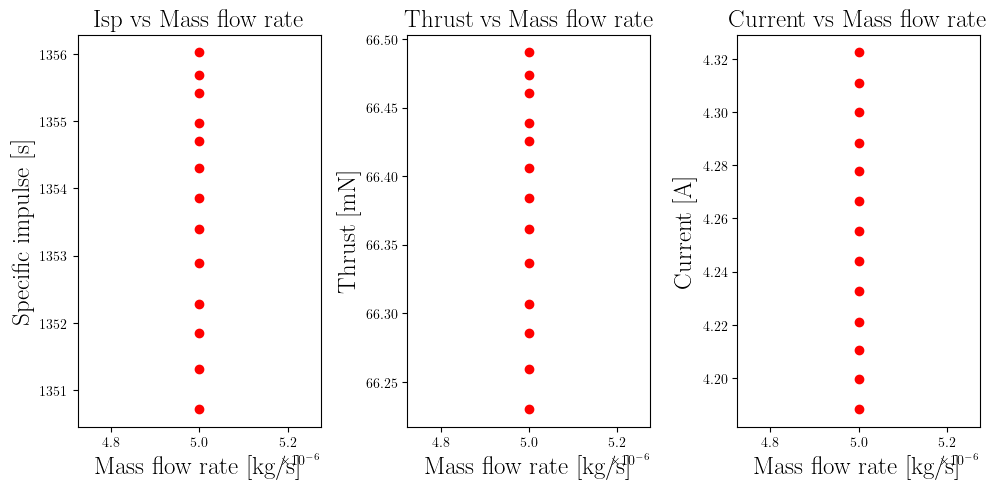

In [153]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].plot(mdot_vec, Isp_vec, 'ro')
ax[0].set_xlabel(r'Mass flow rate [kg/s]', fontsize=18)
ax[0].set_ylabel(r'Specific impulse [s]', fontsize=18)
ax[0].set_title('Isp vs Mass flow rate', fontsize=18)
ax[1].plot(mdot_vec, thrust_vec, 'ro')
ax[1].set_xlabel(r'Mass flow rate [kg/s]', fontsize=18)
ax[1].set_ylabel(r'Thrust [mN]', fontsize=18)
ax[1].set_title('Thrust vs Mass flow rate', fontsize=18)
ax[2].plot(mdot_vec, J_vec, 'ro')
ax[2].set_xlabel(r'Mass flow rate [kg/s]', fontsize=18)
ax[2].set_ylabel(r'Current [A]', fontsize=18)
ax[2].set_title('Current vs Mass flow rate', fontsize=18)
plt.tight_layout()
# plt.savefig(ResultsFigs+"/Eng_params.png", bbox_inches='tight')b

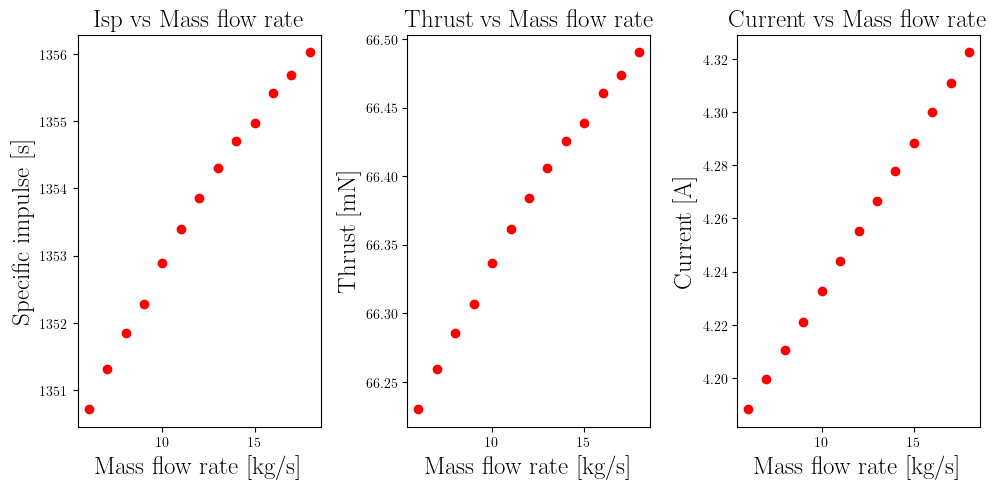

In [154]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].plot(Te_Cath_vec, Isp_vec, 'ro')
ax[0].set_xlabel(r'Mass flow rate [kg/s]', fontsize=18)
ax[0].set_ylabel(r'Specific impulse [s]', fontsize=18)
ax[0].set_title('Isp vs Mass flow rate', fontsize=18)
ax[1].plot(Te_Cath_vec, thrust_vec, 'ro')
ax[1].set_xlabel(r'Mass flow rate [kg/s]', fontsize=18)
ax[1].set_ylabel(r'Thrust [mN]', fontsize=18)
ax[1].set_title('Thrust vs Mass flow rate', fontsize=18)
ax[2].plot(Te_Cath_vec, J_vec, 'ro')
ax[2].set_xlabel(r'Mass flow rate [kg/s]', fontsize=18)
ax[2].set_ylabel(r'Current [A]', fontsize=18)
ax[2].set_title('Current vs Mass flow rate', fontsize=18)
plt.tight_layout()
# plt.savefig(ResultsFigs+"/Eng_params.png", bbox_inches='tight')

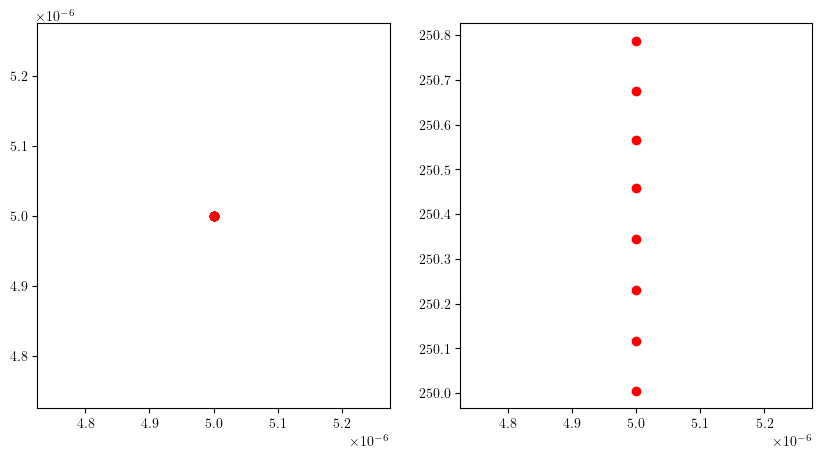

In [124]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(mdot_vec, mdot_vec, 'ro')
plt.subplot(1, 2, 2)
plt.plot(mdot_vec, V_vec, 'ro')


In [51]:
def compute_Kel(Te):
    """This function calculates the ionization rate"""
    # Polynomial coefficients
    c0 = -3.04474930e01
    c1 = 1.89683694e00
    c2 = -6.63807968e-01
    c3 = 9.37924042e-03
    c4 = 2.19404998e-02
    c5 = -2.27126387e-03

    # Compute the natural logarithm of Te
    log_Te = np.log(Te)

    # Manually evaluate the polynomial using Horner's method (unrolled loop)
    result = c5
    result = result * log_Te + c4
    result = result * log_Te + c3
    result = result * log_Te + c2
    result = result * log_Te + c1
    result = result * log_Te + c0

    # Return the exponential of the polynomial result
    return np.exp(result)

def compute_Kiz(Te):
    # Xenon ionization
    K0 = 1.18122959e-13
    epsilon = 12.13
    A = 1.29330521e-01
    B = 1.00068880e-02
    C = 6.97445869e-01

    # Ensure Te is an array for element-wise operations
    Te = np.asarray(Te)

    # Debugging statements
    if np.any(Te < 0):
        print("Te contains negative values:", Te)
    
    if np.any(np.isnan(Te)):
        print("Te contains NaN values:", Te)

    log_arg = 1 + A * Te + B * Te**2
    if np.any(log_arg <= 0):  # Ensuring no negative values inside log
        print("Invalid log argument encountered:", log_arg)

    if np.any(np.isnan(log_arg)):
        print("log_arg contains NaN values:", log_arg)

    log_term = np.log(log_arg)

    if np.any(np.isnan(log_term)):
        print("NaN encountered in log computation:", log_term)
        print("Corresponding log_arg values:", log_arg[np.isnan(log_term)])

    return K0 * np.exp(-epsilon / Te) * (log_term) ** C

def computeEpsilonLoss(Te):
    def computeKprocess(K0, epsilon, A, B, C):
        arg = 1 + A * Te + B * Te**2
        if np.any(arg <= 1):
            arg = 1.0
        if (np.any(np.isnan( K0 * np.exp(-epsilon / Te) * (np.log(arg) ** C)))):
            print("NaN encountered in computeKprocess:", K0, epsilon, A, B, C)
            print("Te value:", Te)
            print("Corresponding log argument:", arg)
            print("Corresponding log term:", np.log(arg))
        return K0 * np.exp(-epsilon / Te) * (np.log(arg)) ** C

    K_iz = computeKprocess(
        1.18122959e-13, 12.13, 1.29330521e-01, 1.00068880e-02, 6.97445869e-01
    )
    K_ex1 = computeKprocess(
        2.37016128e-14, 8.315, 7.99682247e-02, -5.91358673e-04, 4.51997276e-01
    )
    K_ex2 = computeKprocess(
        9.02951389e-15, 9.447, 3.12421531e00, -3.01100074e-02, 5.59327899e-01
    )
    K_ex3 = computeKprocess(
        1.66394517e-14, 9.917, 2.83412200e00, -2.66987222e-02, 6.98378384e-01
    )
    K_ex4 = computeKprocess(
        7.64651071e-15, 11.70, 7.35828827e-01, -5.08912904e-03, 1.39724961e00
    )

    return (
        12.13
        + (K_ex1 * 8.315 + K_ex2 * 9.447 + K_ex3 * 9.917 + K_ex4 * 11.70) / K_iz
        + 3 * m / M * compute_Kel(Te) * Te / K_iz
    )

In [52]:
epsilon_val = []
for Te_val in np.arange(1, 150., 0.1):
    epsilon_val.append(computeEpsilonLoss(Te_val))

eps_c = np.loadtxt(
   "/home/petronio/Nextcloud/code/projet_code_stationnaire_EA/library_code/coll_data/EpsC_xenon.csv",
    delimiter=",",
)
# Perform exponential interpolation
x = eps_c[:, 0]
y = eps_c[:, 1]
# Create an exponential interpolation function
from scipy.interpolate import interp1d
interp_func_eps_c = interp1d(x, np.log(y), kind="linear", fill_value="extrapolate")

(1.0, 1000.0)

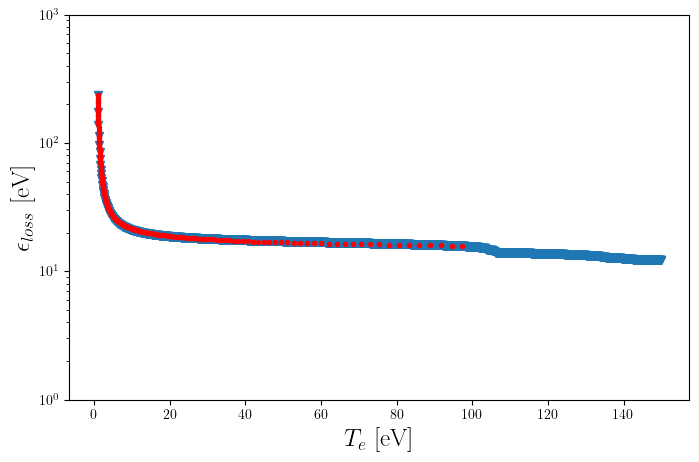

In [53]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, 150., 0.1), epsilon_val, marker="v")
plt.plot(
    eps_c[:, 0], eps_c[:, 1], "ro", label="Experimental data", markersize=3
)
plt.xlabel(r"$T_e$ [eV]", fontsize=18)
plt.yscale("log")
plt.ylabel(r"$\epsilon_{loss}$ [eV]", fontsize=18)
plt.ylim(1e0, 1e3)